# KG-Commit — Final Experiments

**The five canonical graph-inference methods evaluated online (prequentially) on a
family of six knowledge graphs of increasing richness (Groovy, 8,059 labelled
commits). No commit text ($X$) anywhere.**

### Methods (rows)
| | method | paradigm |
|--|--|--|
| RN | Relational neighbour (wvRN) | collective classification |
| PPR | Personalized PageRank / RWR | random walk |
| LP | Label propagation | label diffusion |
| DW | DeepWalk embedding | random-walk node embedding |
| KGE | DistMult | knowledge-graph embedding |

### Graphs (columns), all sharing the Core commit–file–developer layer
`Core` · `Core+AST` · `Core+CFG` · `Core+DFG` · `Core+PDG` · **`Core+AST+CSTG` (final)**

Reading a **row** answers *which graph helps this method* (the *which-subgraph* RQ);
reading a **column** answers *which method wins on this graph* (the *which-method*
RQ). The final graph adds the CSTG term-hubs so the walks/embeddings also traverse
the semantic signal.

In [1]:
import pickle
from pathlib import Path
import numpy as np, pandas as pd
from IPython.display import Image, display

OUT = Path.cwd()
while not (OUT / "outputs").exists() and OUT != OUT.parent:
    OUT = OUT.parent
OUT = OUT / "outputs"
R = pickle.load(open(OUT / "final_experiments_results.pkl", "rb"))
FIG = OUT / "figures" / "v4" / "final"

GRAPHS = ["core","ast","cfg","dfg","pdg","final"]
GNAME = {"core":"Core","ast":"Core+AST","cfg":"Core+CFG","dfg":"Core+DFG",
         "pdg":"Core+PDG","final":"Core+AST+CSTG"}
METHODS = ["RN","PPR","LP","DW","KGE"]
M7 = [("Precision","Prec."),("Recall","Rec."),("Macro_F1","Macro-F1"),
      ("Buggy_F1","Buggy-F1"),("G_Mean","G-Mean"),("AUC","AUC"),("ACC","Acc.")]
print(f"warmup={R['meta']['warmup']}  N={R['meta']['N']}  "
      f"eval={R['meta']['N']-R['meta']['warmup']} commits scored online")

warmup=3223  N=8059  eval=4836 commits scored online


## 1. Results — seven per-metric tables (methods × graphs)

One table per metric; **best method per graph in bold** (green). This is the two-RQ answer table.

In [2]:
for mk, lbl in M7:
    df = pd.DataFrame({GNAME[g]:{m:R[g][m]["metrics"][mk] for m in METHODS} for g in GRAPHS})
    df = df.loc[METHODS, [GNAME[g] for g in GRAPHS]]
    display(df.style.format("{:.3f}").highlight_max(axis=0, color="#d5efdf")
            .set_caption(f"{lbl} — 5 methods x 6 graphs (best method per graph highlighted)"))

,Core,Core+AST,Core+CFG,Core+DFG,Core+PDG,Core+AST+CSTG
RN,0.373,0.299,0.306,0.312,0.304,0.304
PPR,0.371,0.361,0.357,0.365,0.354,0.430
LP,0.318,0.302,0.310,0.321,0.307,0.380
DW,0.264,0.342,0.339,0.339,0.333,0.368
KGE,0.299,0.373,0.373,0.310,0.311,0.376


,Core,Core+AST,Core+CFG,Core+DFG,Core+PDG,Core+AST+CSTG
RN,0.730,0.900,0.857,0.853,0.861,0.900
PPR,0.761,0.819,0.839,0.835,0.841,0.781
LP,0.820,0.884,0.884,0.866,0.884,0.788
DW,0.792,0.638,0.788,0.797,0.788,0.726
KGE,0.827,0.727,0.752,0.811,0.802,0.705


,Core,Core+AST,Core+CFG,Core+DFG,Core+PDG,Core+AST+CSTG
RN,0.603,0.457,0.487,0.499,0.481,0.470
PPR,0.600,0.584,0.576,0.588,0.572,0.660
LP,0.518,0.471,0.487,0.514,0.481,0.610
DW,0.407,0.573,0.556,0.555,0.548,0.598
KGE,0.479,0.603,0.602,0.505,0.510,0.607


,Core,Core+AST,Core+CFG,Core+DFG,Core+PDG,Core+AST+CSTG
RN,0.493,0.449,0.451,0.457,0.449,0.454
PPR,0.499,0.501,0.501,0.508,0.498,0.555
LP,0.459,0.451,0.459,0.468,0.455,0.513
DW,0.396,0.445,0.474,0.476,0.469,0.488
KGE,0.439,0.493,0.498,0.449,0.449,0.491


,Core,Core+AST,Core+CFG,Core+DFG,Core+PDG,Core+AST+CSTG
RN,0.662,0.532,0.563,0.576,0.557,0.545
PPR,0.665,0.658,0.653,0.664,0.649,0.720
LP,0.594,0.547,0.565,0.593,0.558,0.678
DW,0.473,0.620,0.629,0.628,0.621,0.658
KGE,0.553,0.662,0.666,0.580,0.584,0.661


,Core,Core+AST,Core+CFG,Core+DFG,Core+PDG,Core+AST+CSTG
RN,0.696,0.638,0.606,0.632,0.601,0.647
PPR,0.728,0.707,0.713,0.709,0.711,0.780
LP,0.687,0.642,0.660,0.664,0.657,0.735
DW,0.576,0.666,0.677,0.658,0.674,0.710
KGE,0.629,0.709,0.702,0.645,0.629,0.713


,Core,Core+AST,Core+CFG,Core+DFG,Core+PDG,Core+AST+CSTG
RN,0.633,0.458,0.489,0.503,0.483,0.470
PPR,0.625,0.600,0.590,0.603,0.584,0.693
LP,0.526,0.472,0.489,0.519,0.482,0.633
DW,0.407,0.611,0.572,0.569,0.562,0.628
KGE,0.482,0.633,0.629,0.512,0.517,0.641


## 2. Online-evaluation stream plots

The prequential value of each metric over the commit stream (rolling window = 800).
Two complementary views.

### 2a. By method — trends are graphs (35 stream plots)

Five figures (one per method), each with the seven metric panels; within each
panel the six **graphs** are the trends. Shows how graph richness moves each
method's stream (the final graph, bold, is usually on top).

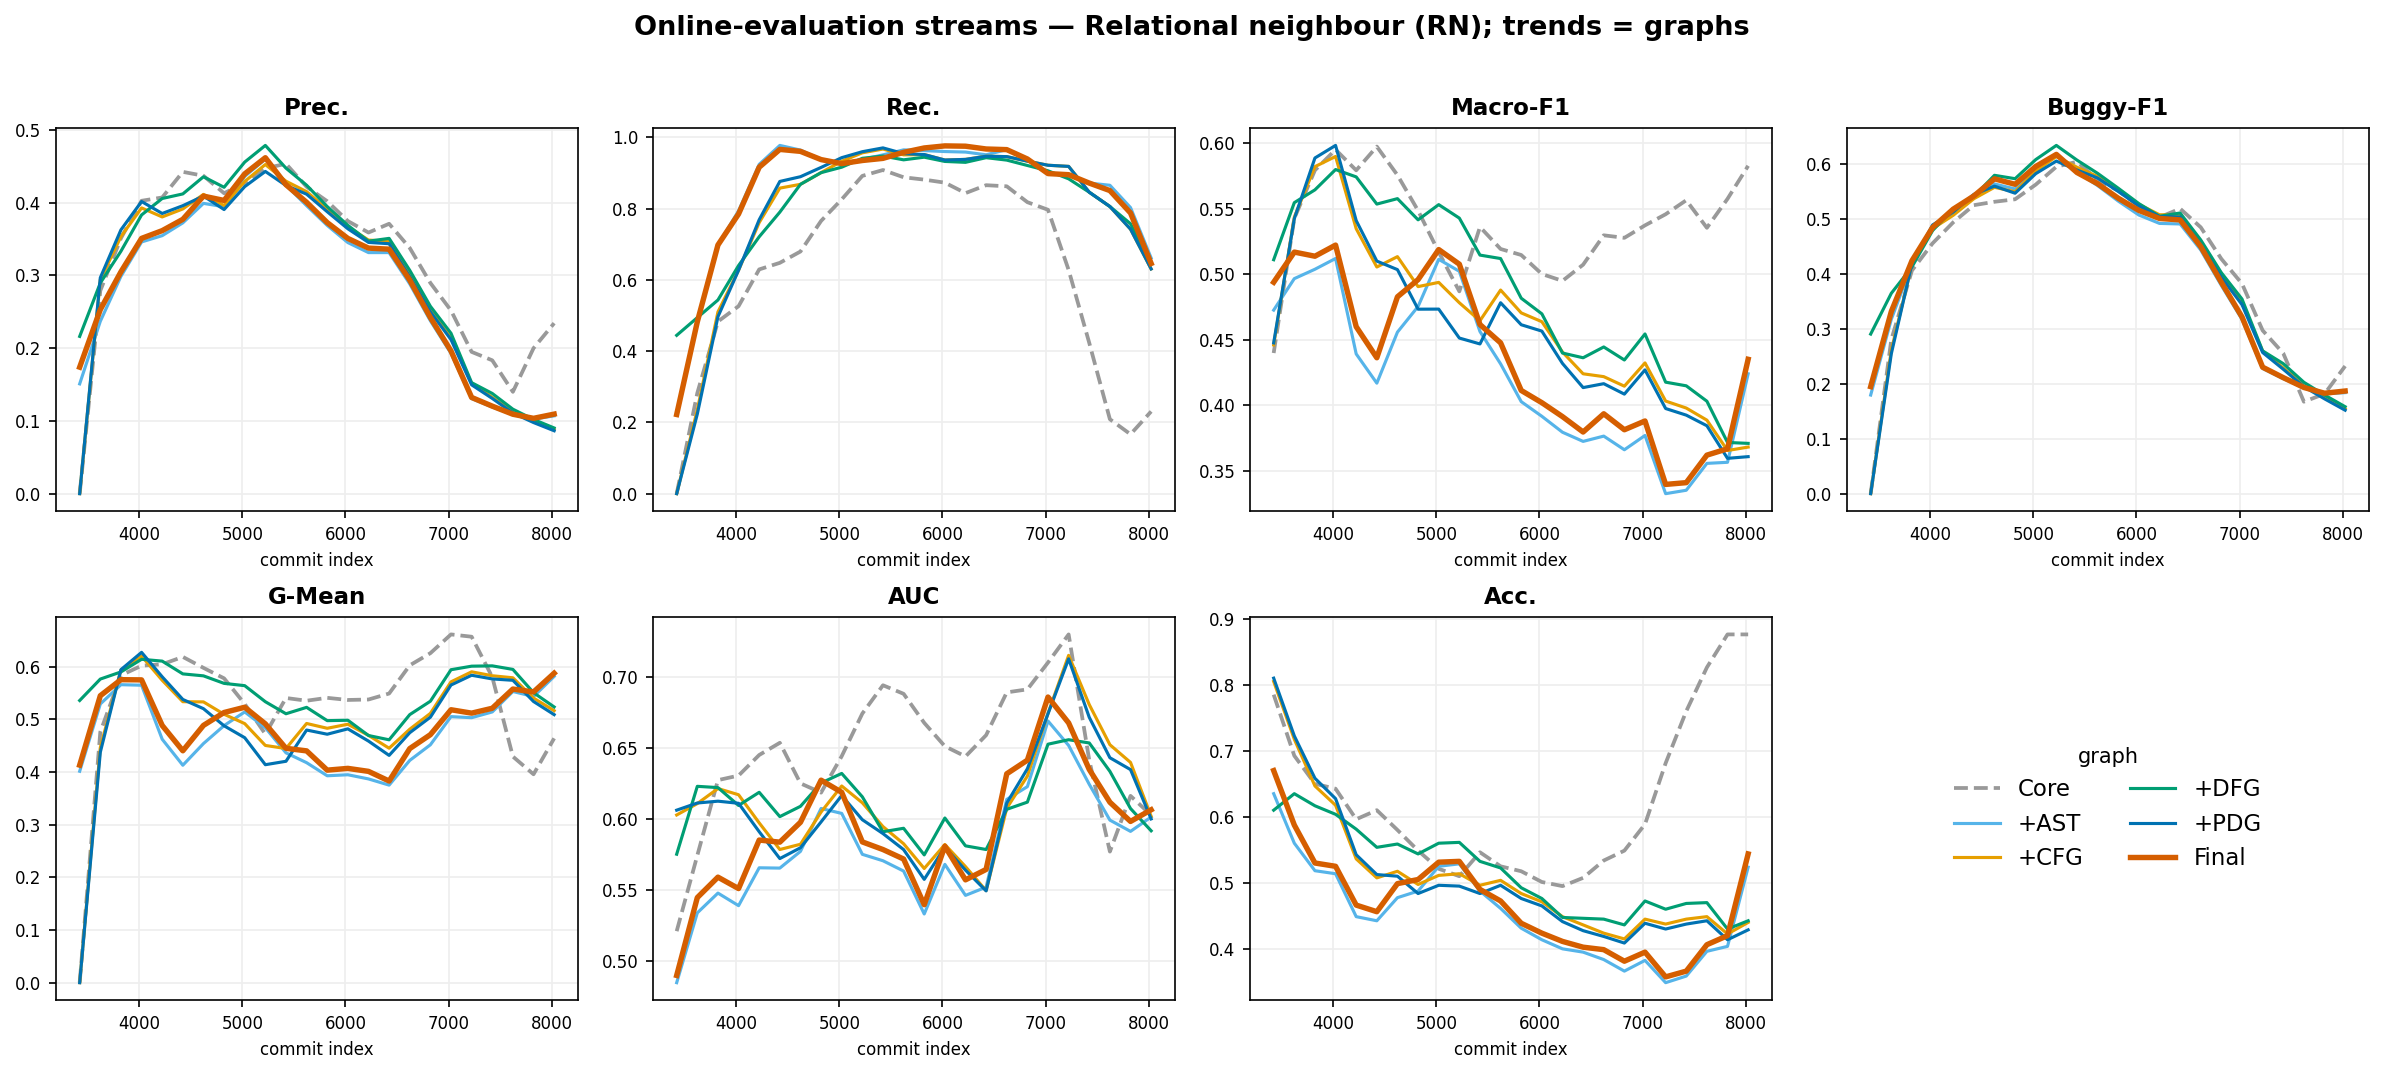

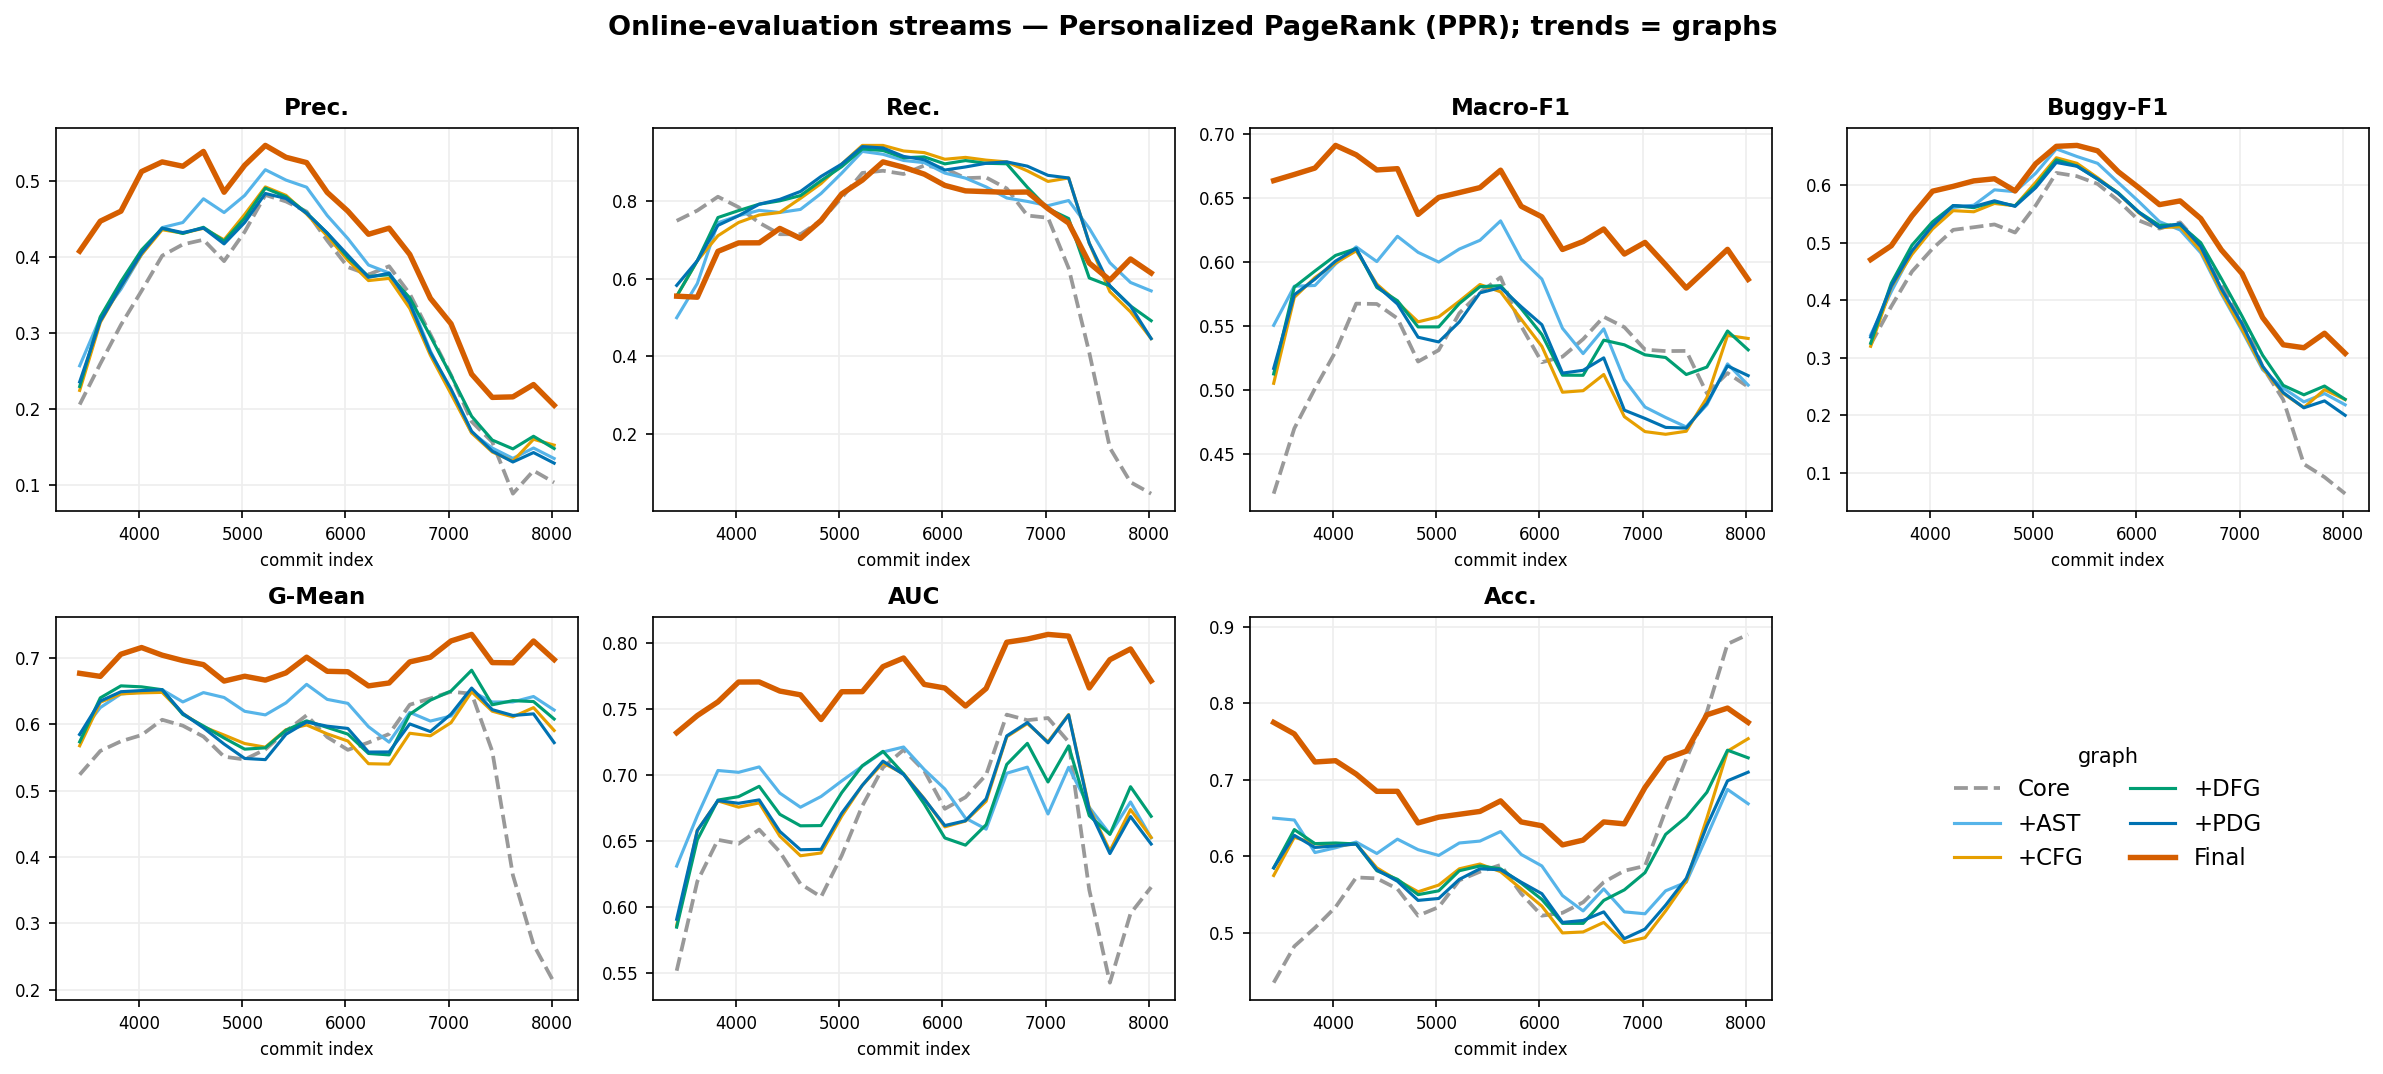

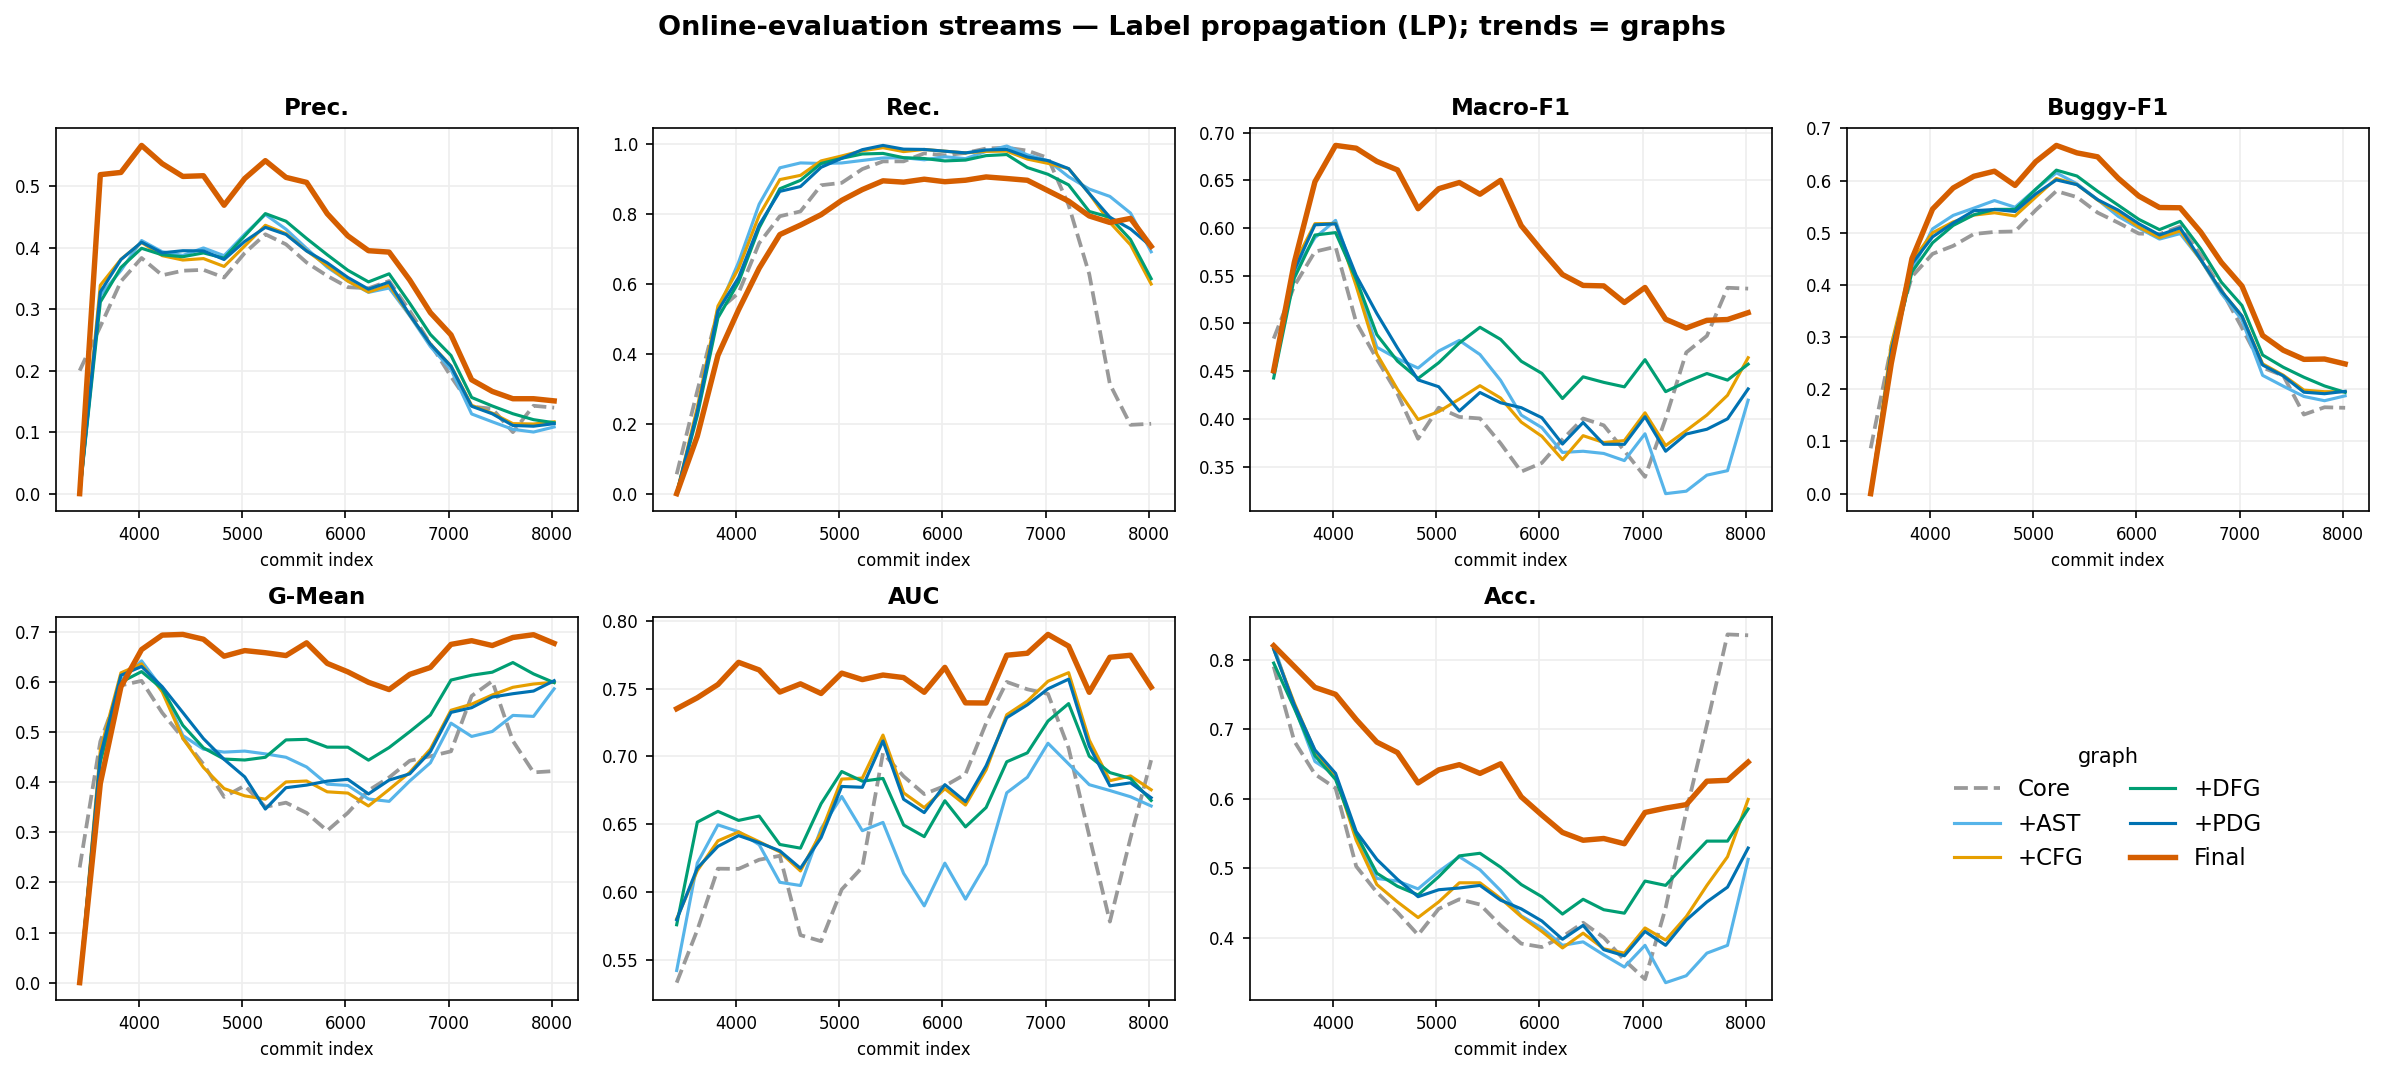

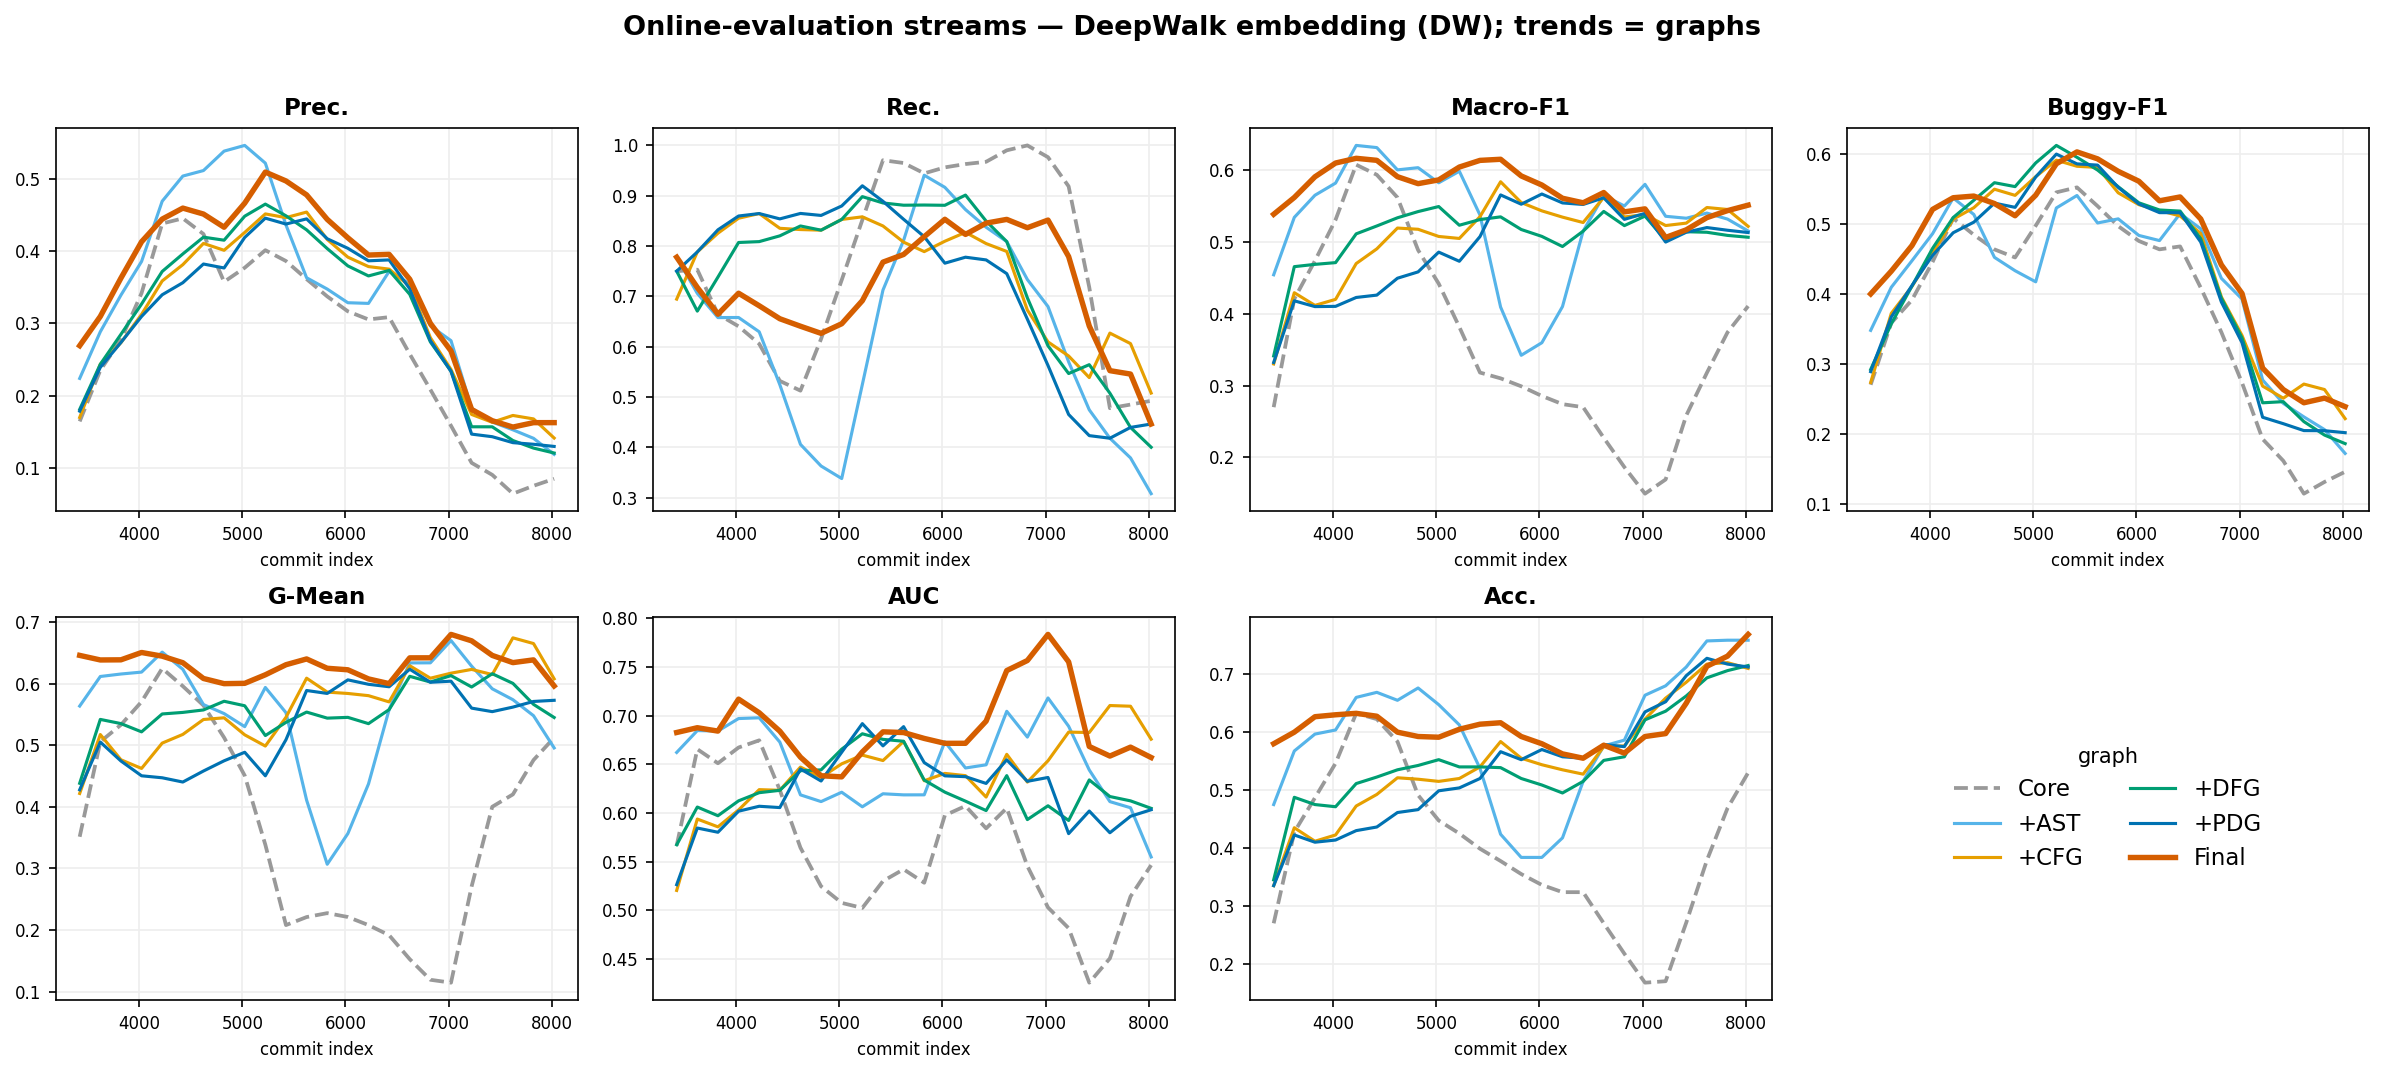

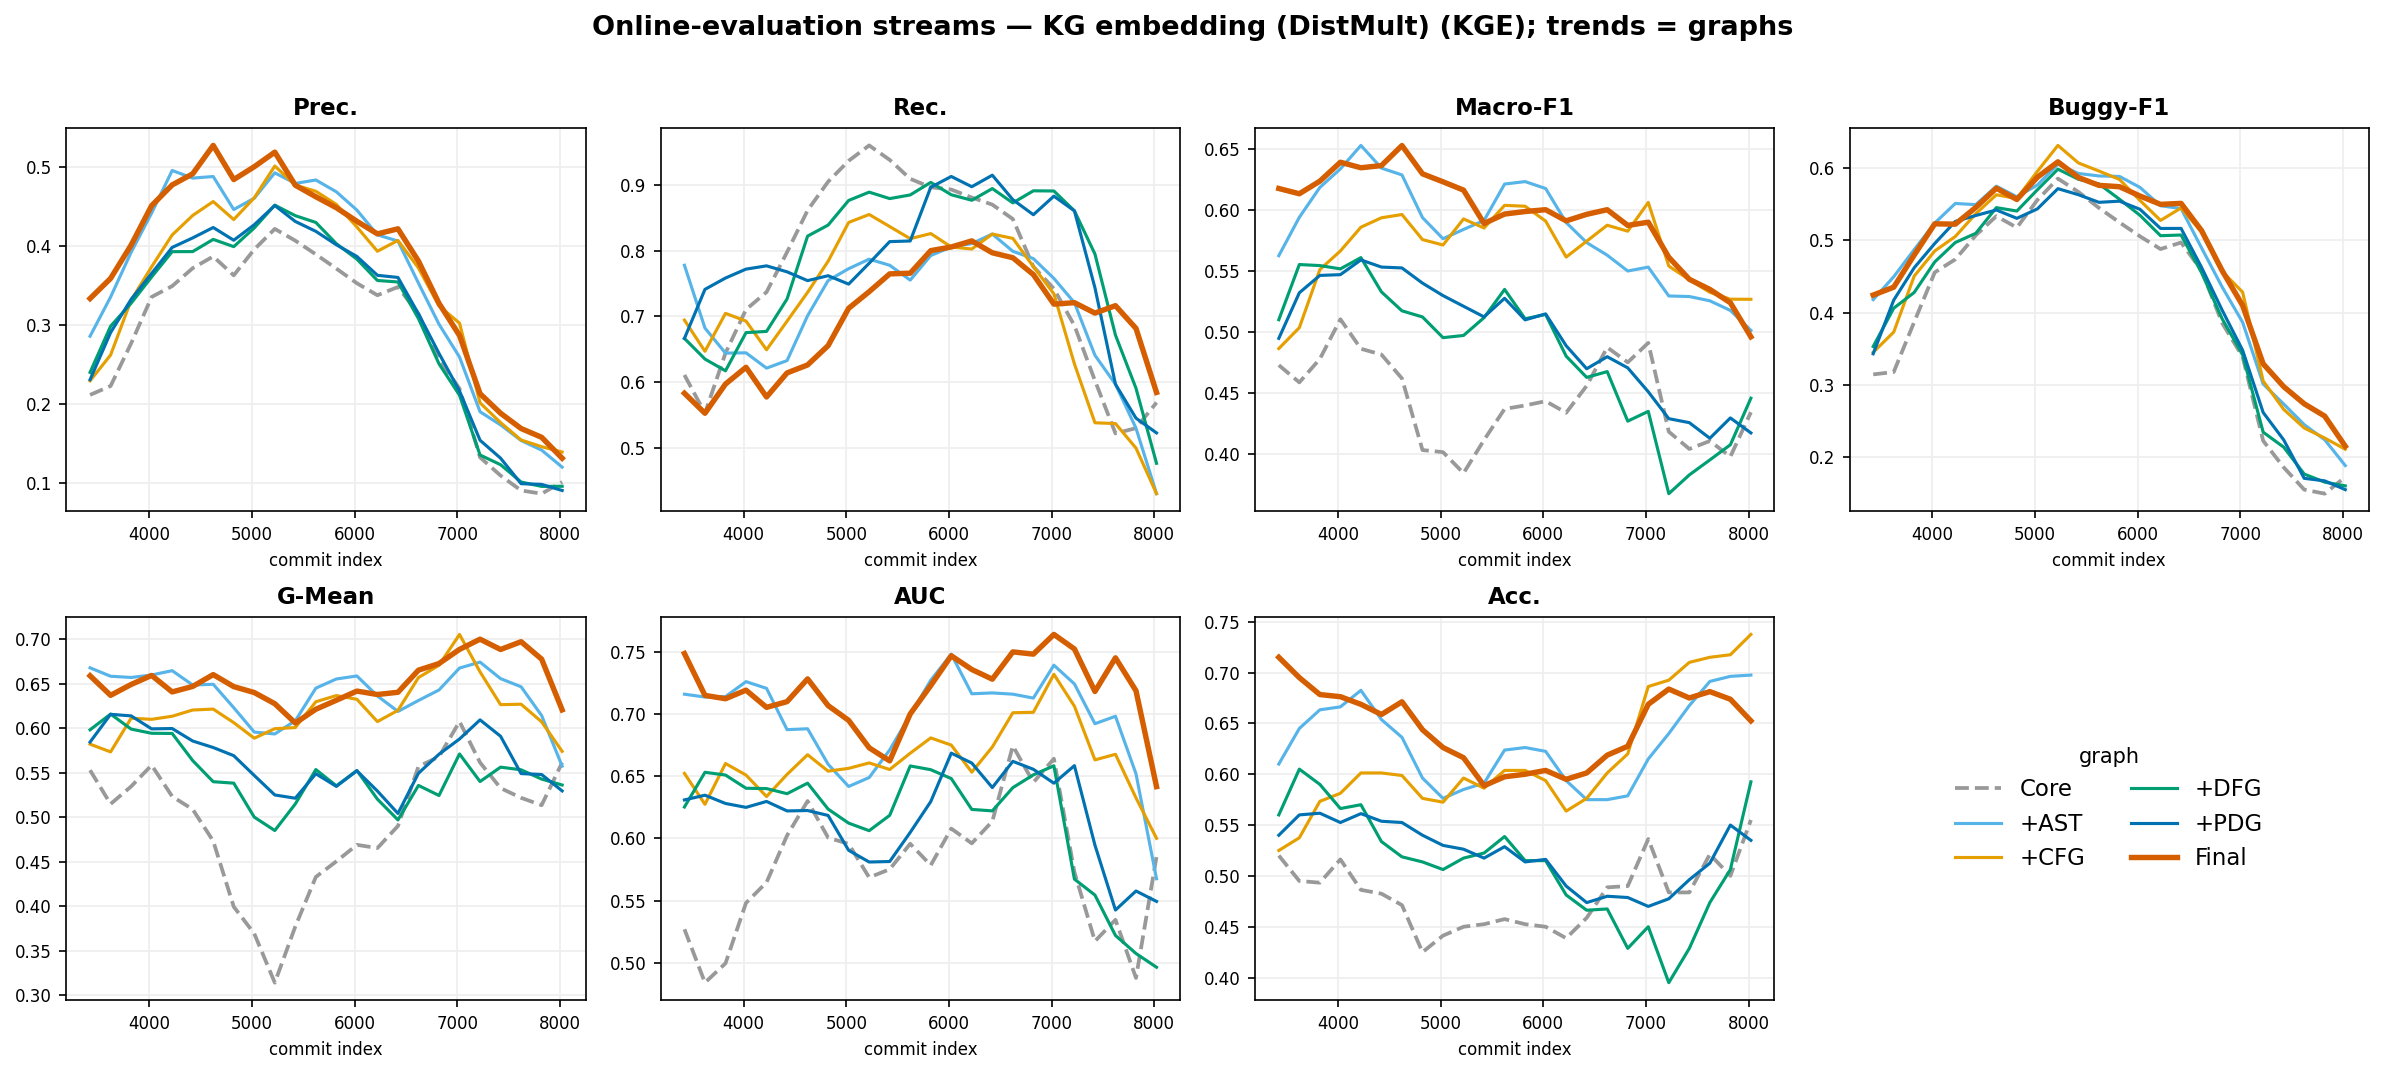

In [3]:
for m in METHODS:
    display(Image(filename=str(FIG / f"fig_final_bymethod_{m}.png")))

### 2b. By graph — trends are methods (42 stream plots)

Six figures (one per graph), each with the seven metric panels; within each panel
the five **methods** are the trends (PPR bold). Shows which method leads on each
graph across the stream.

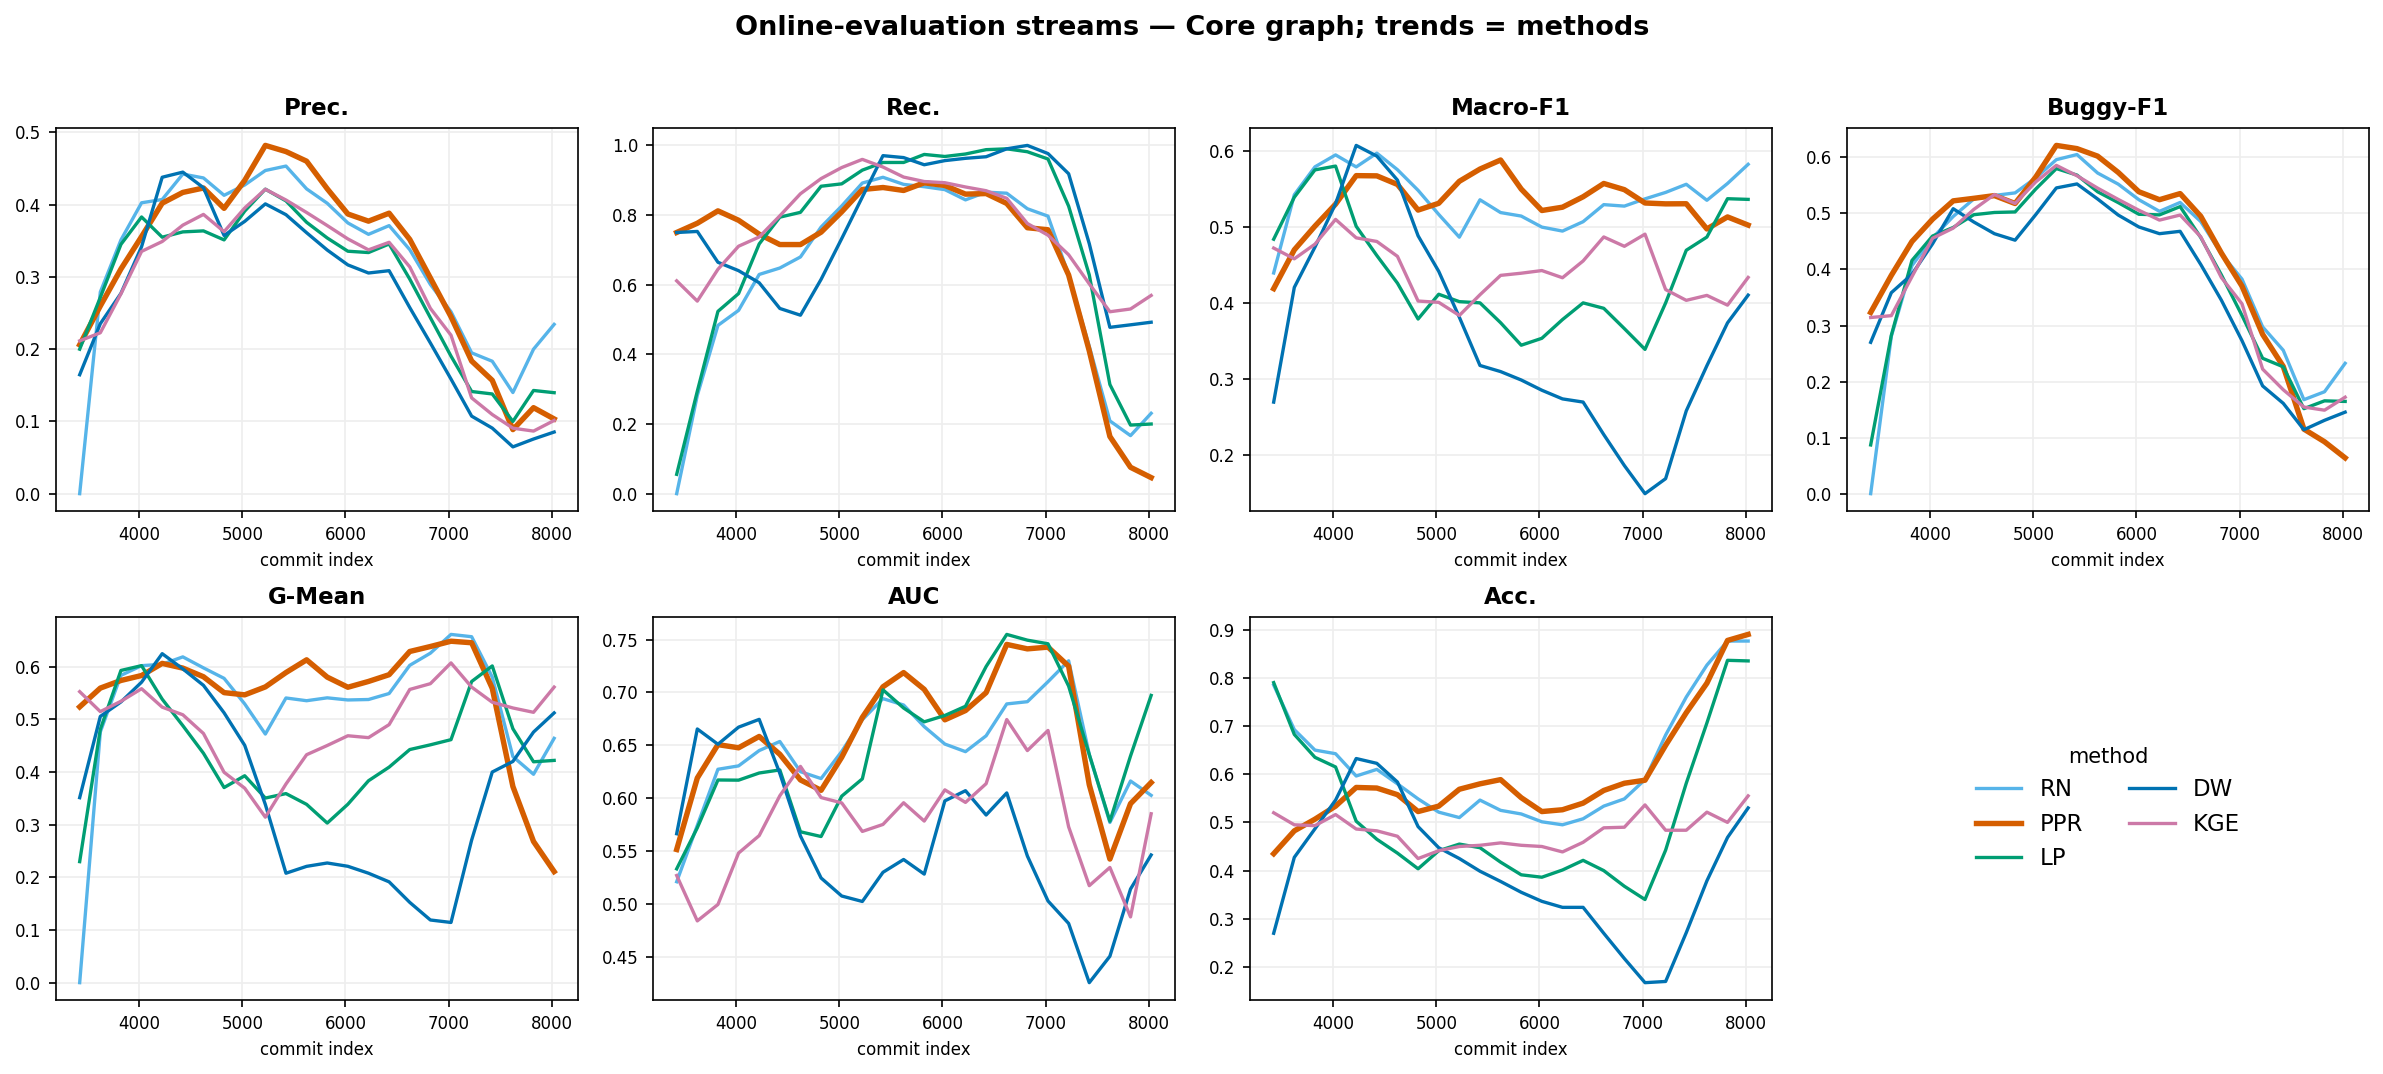

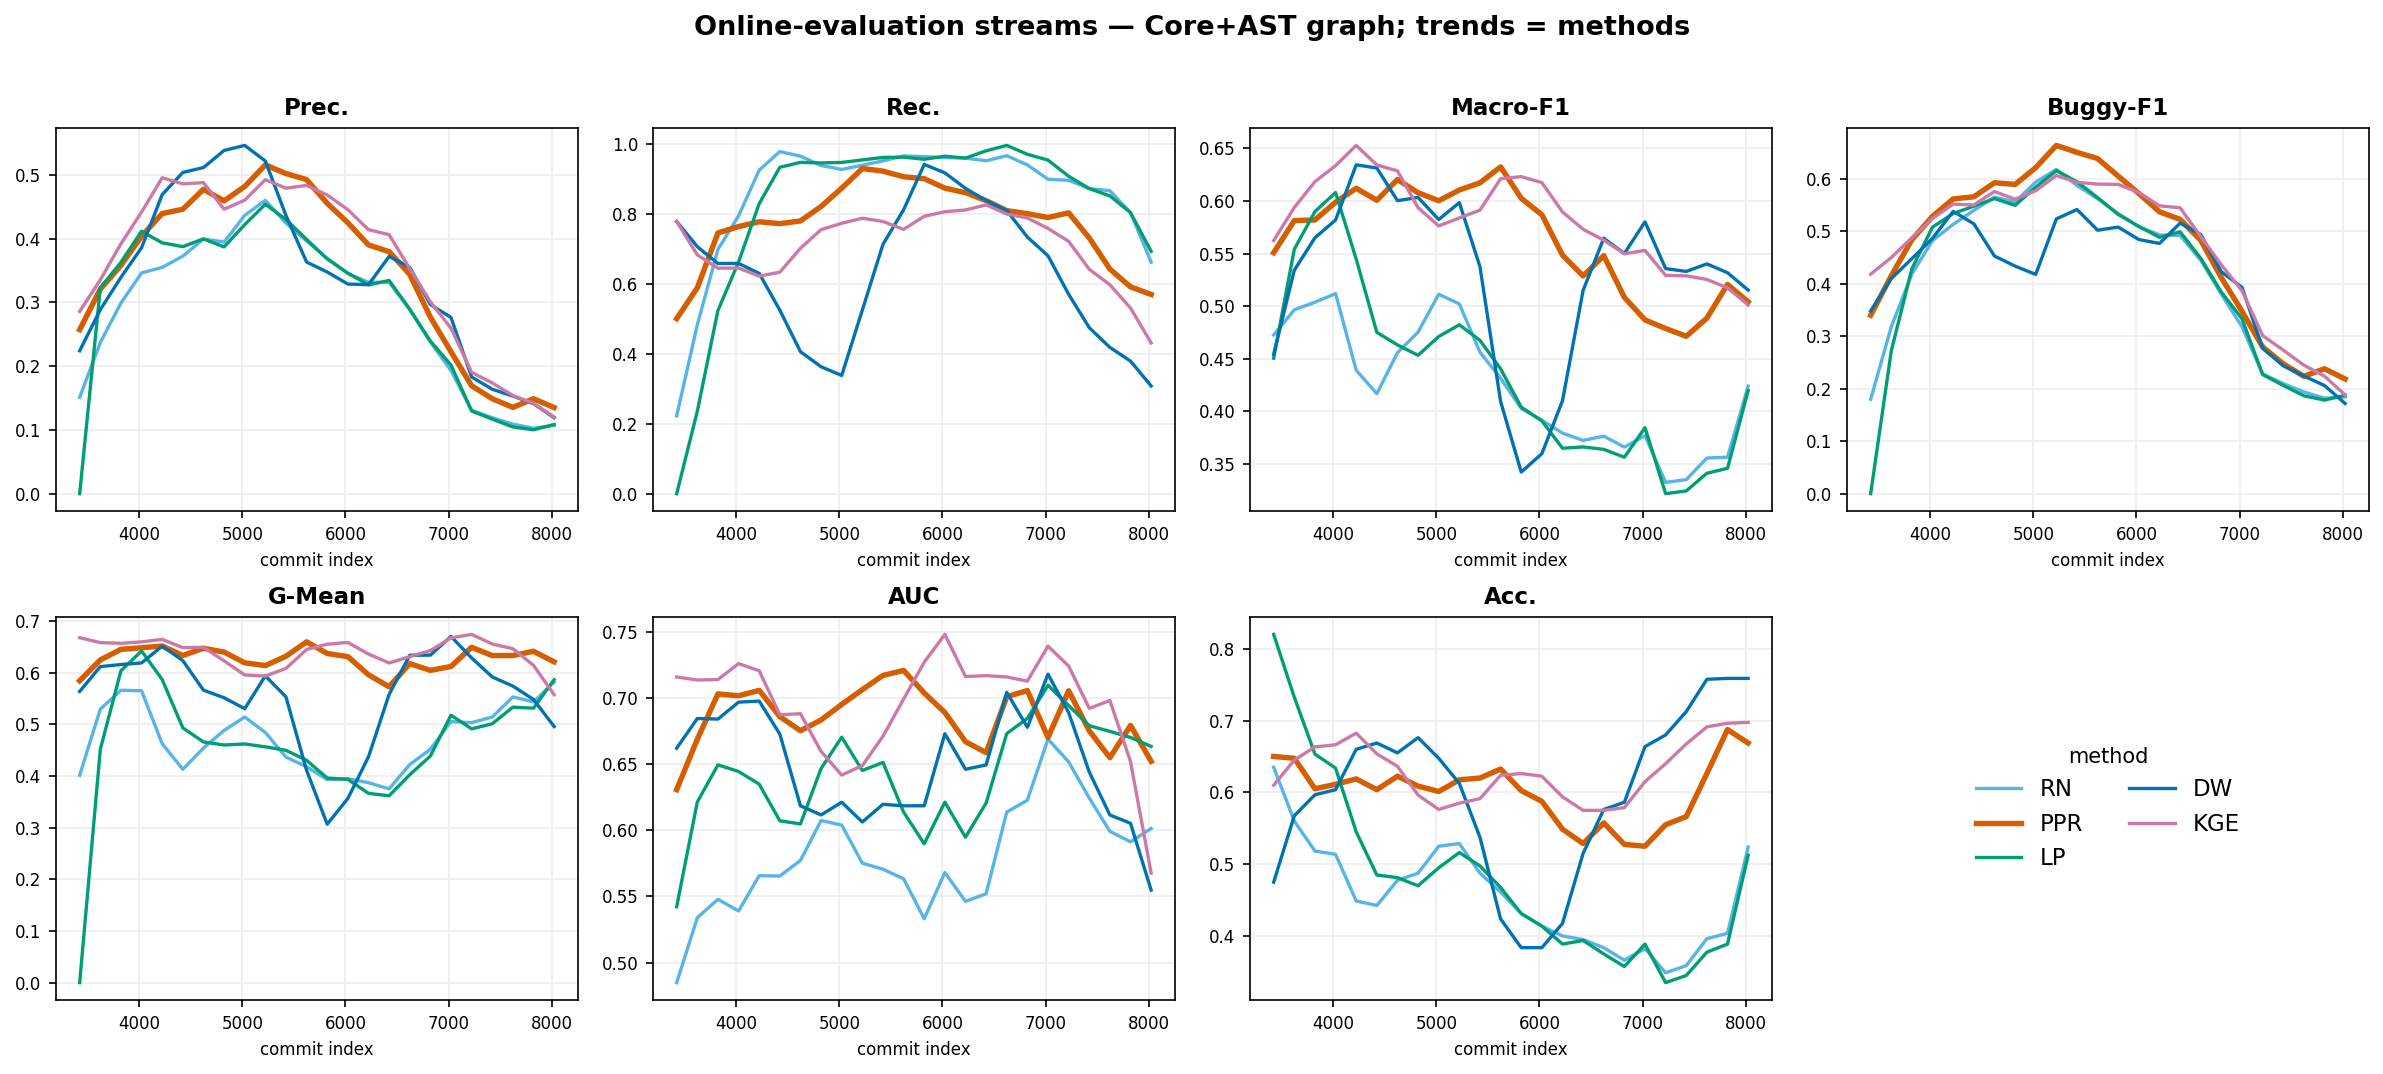

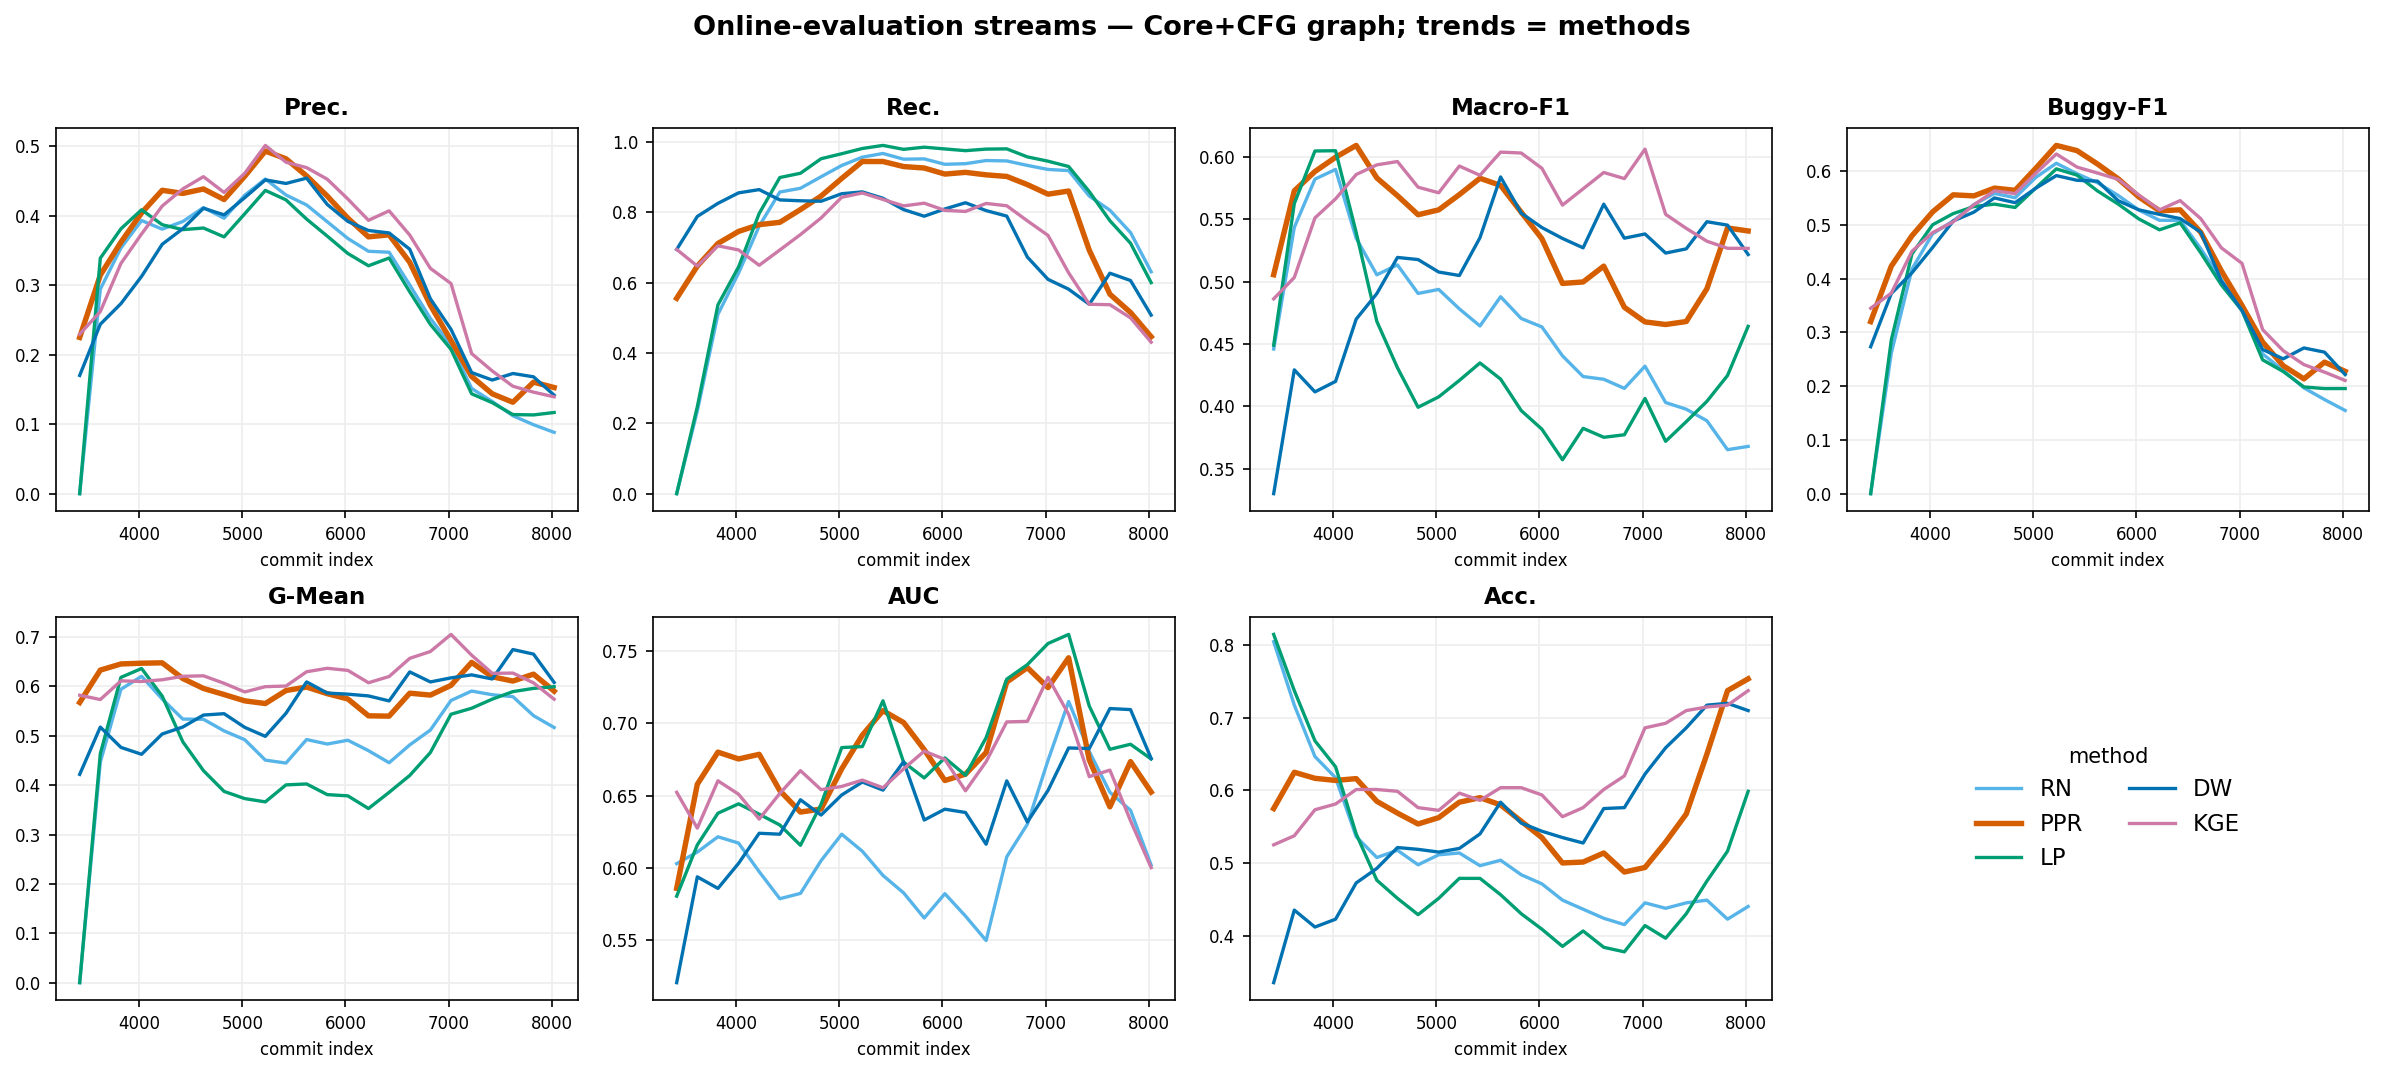

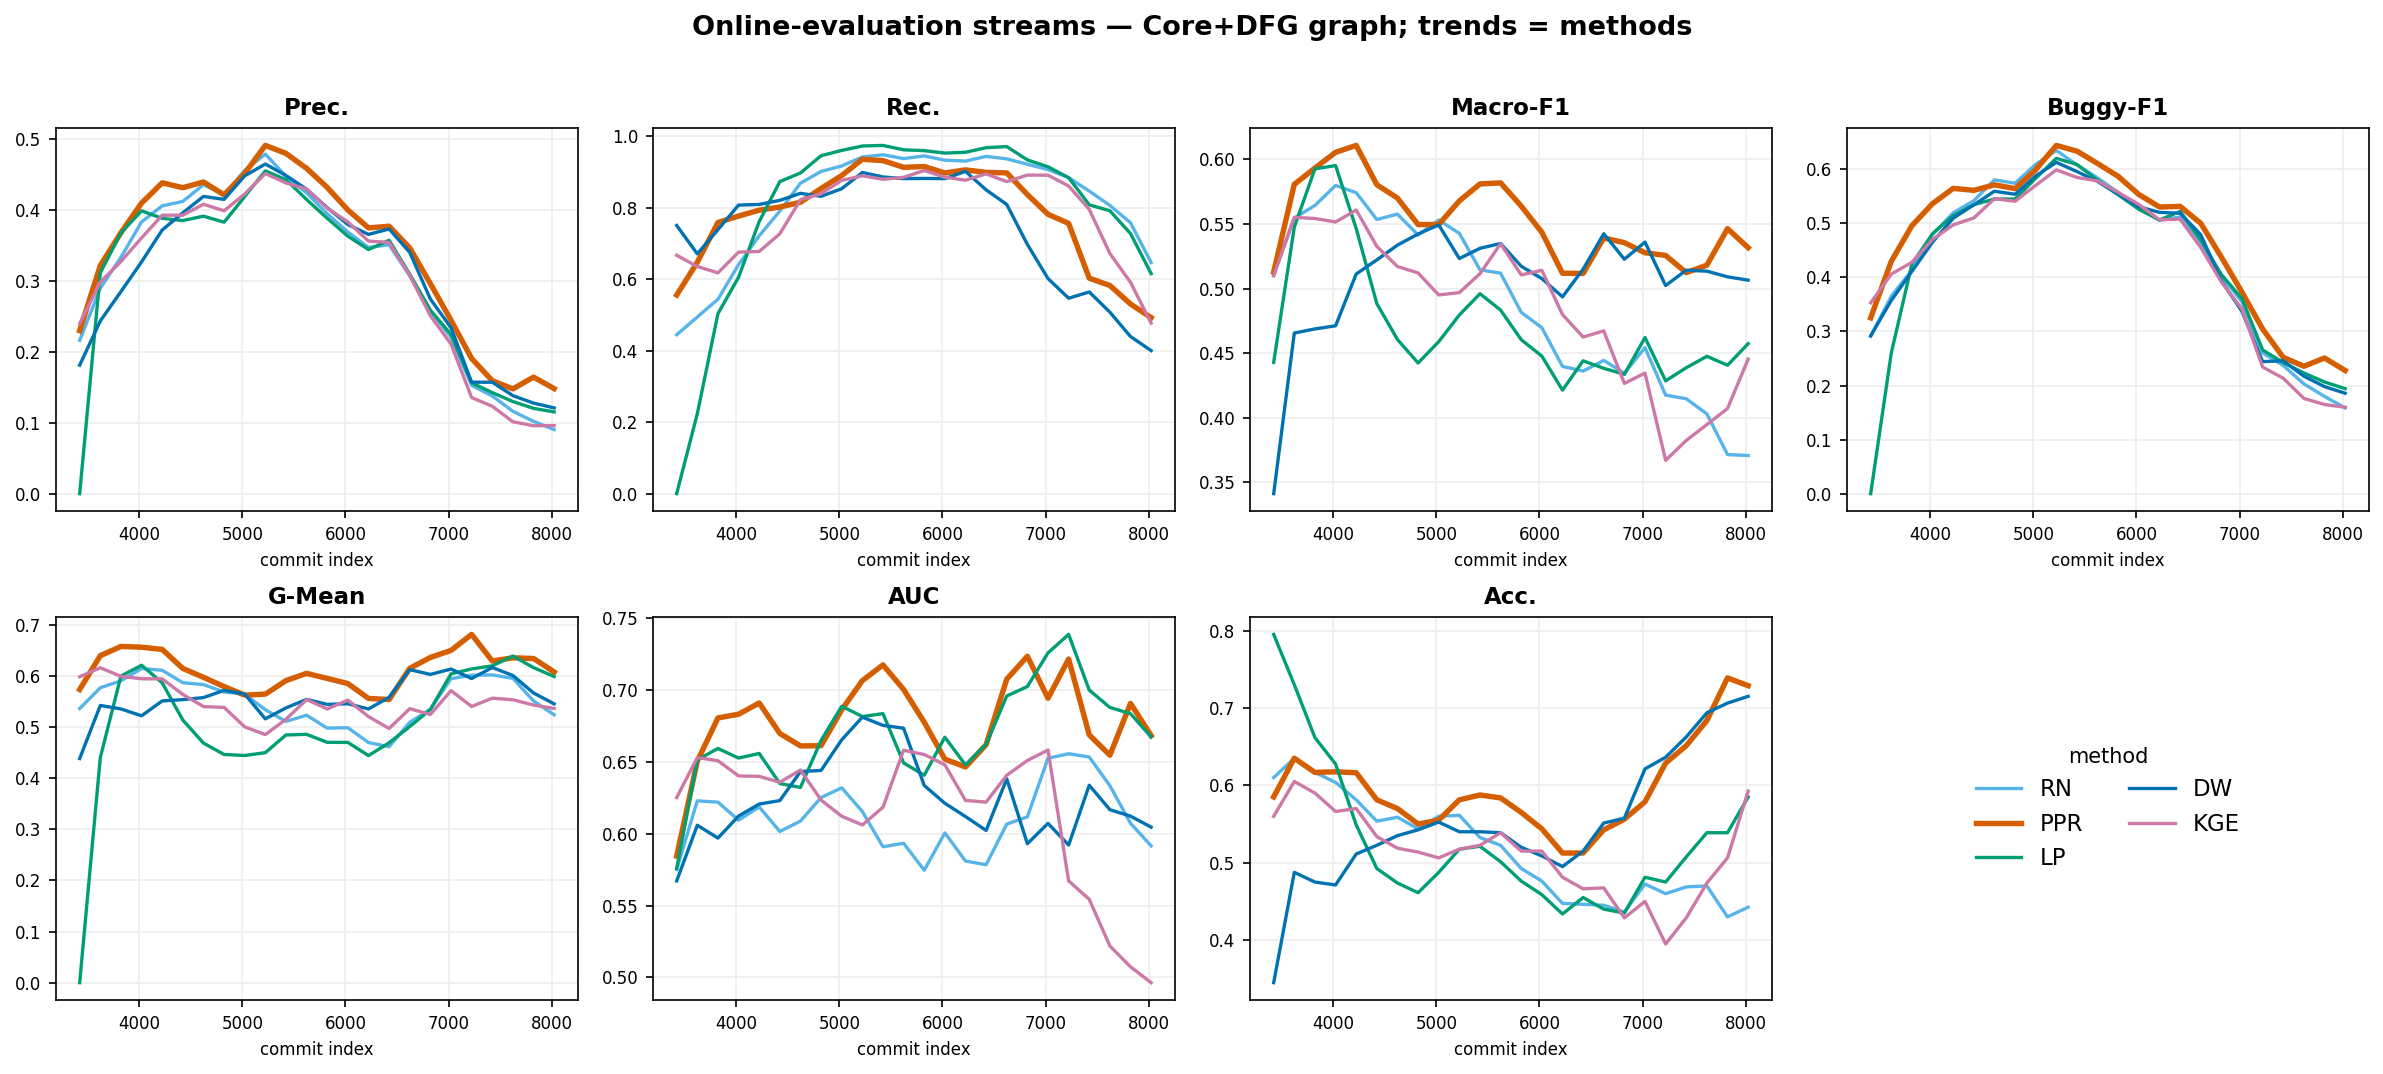

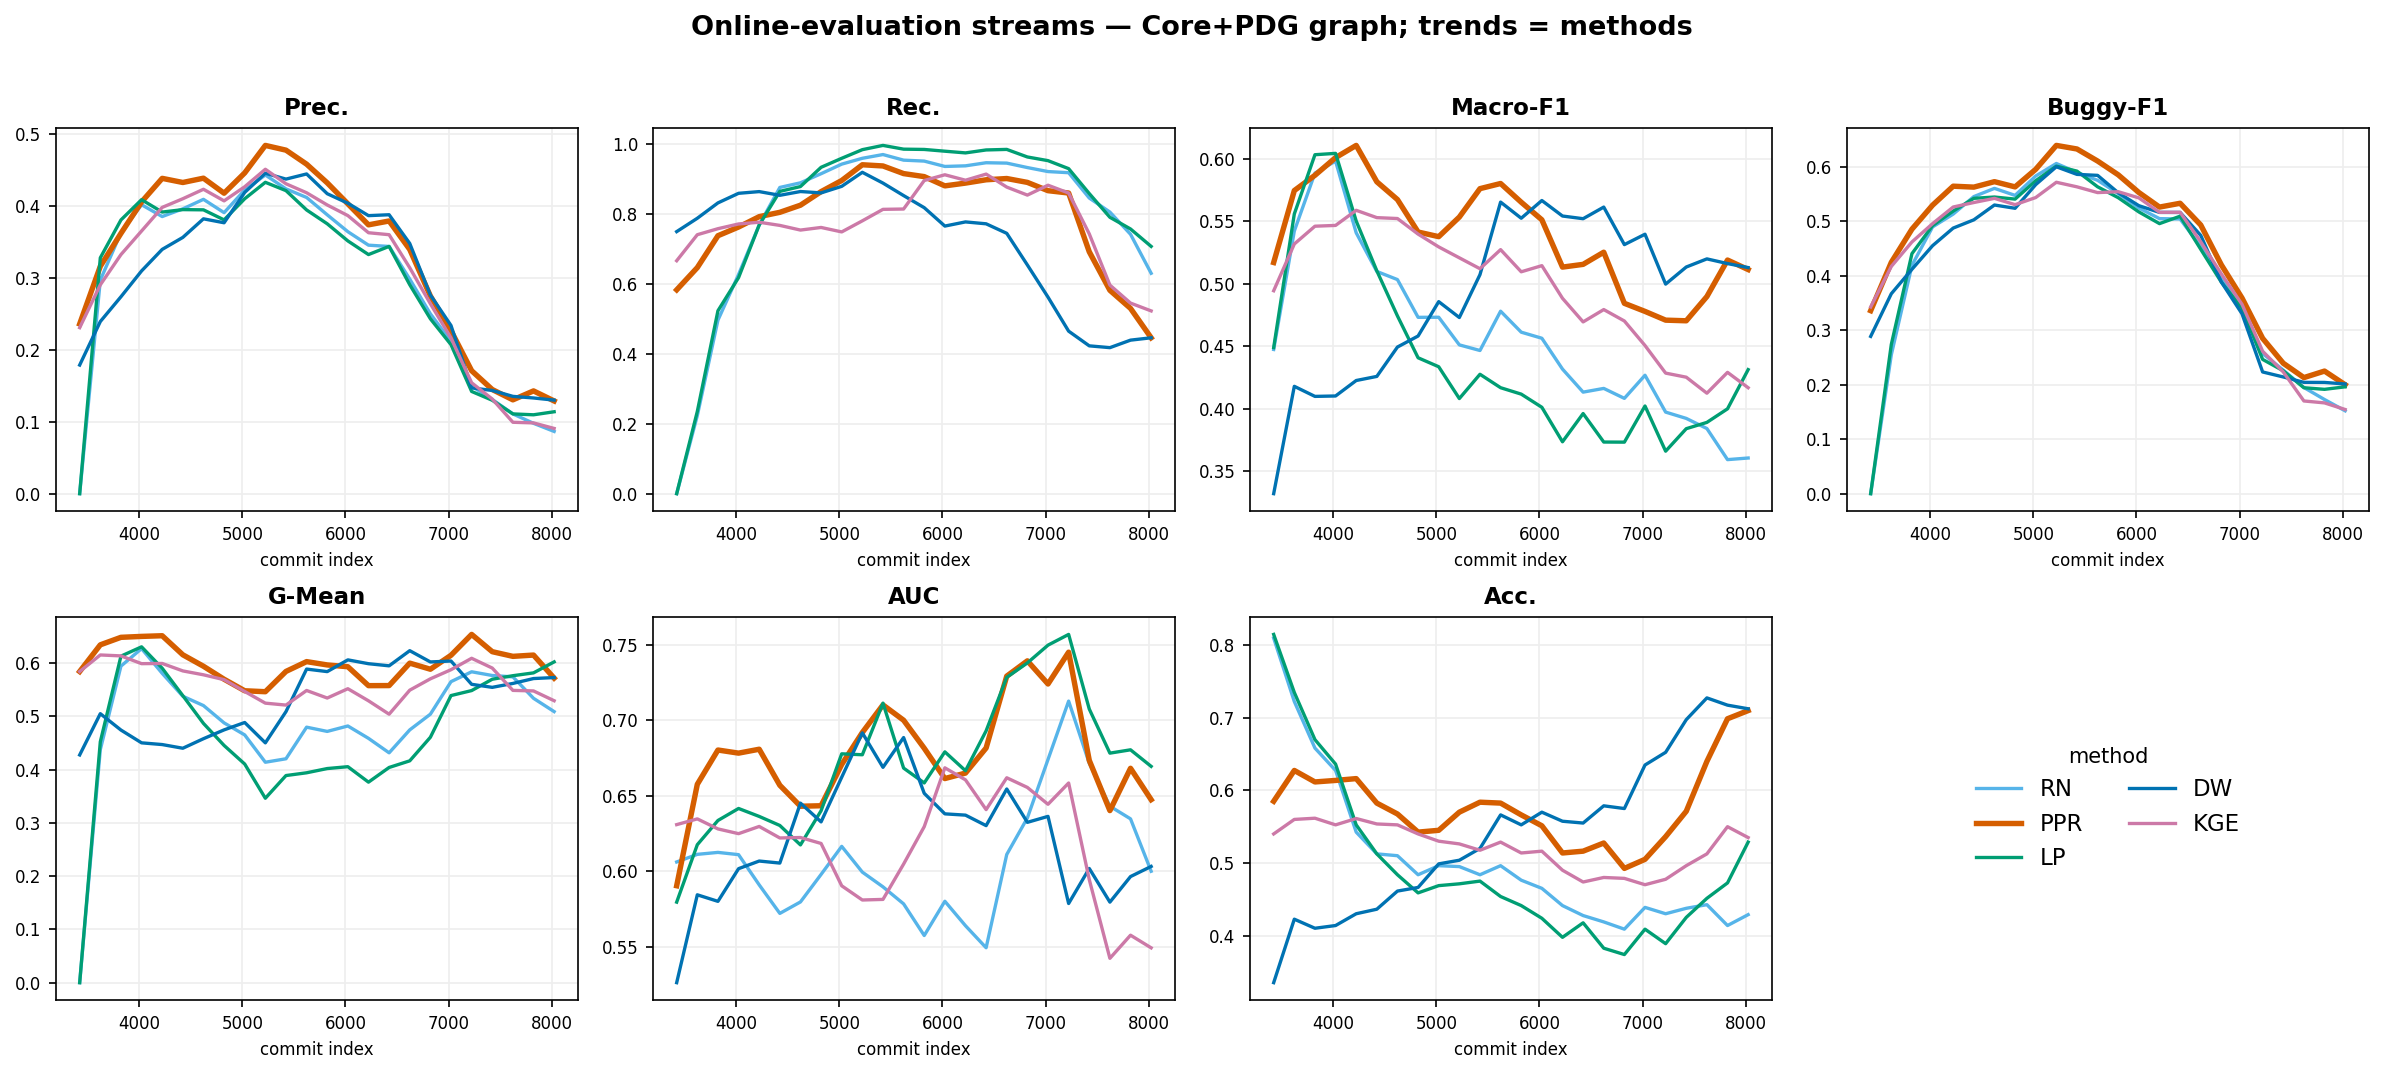

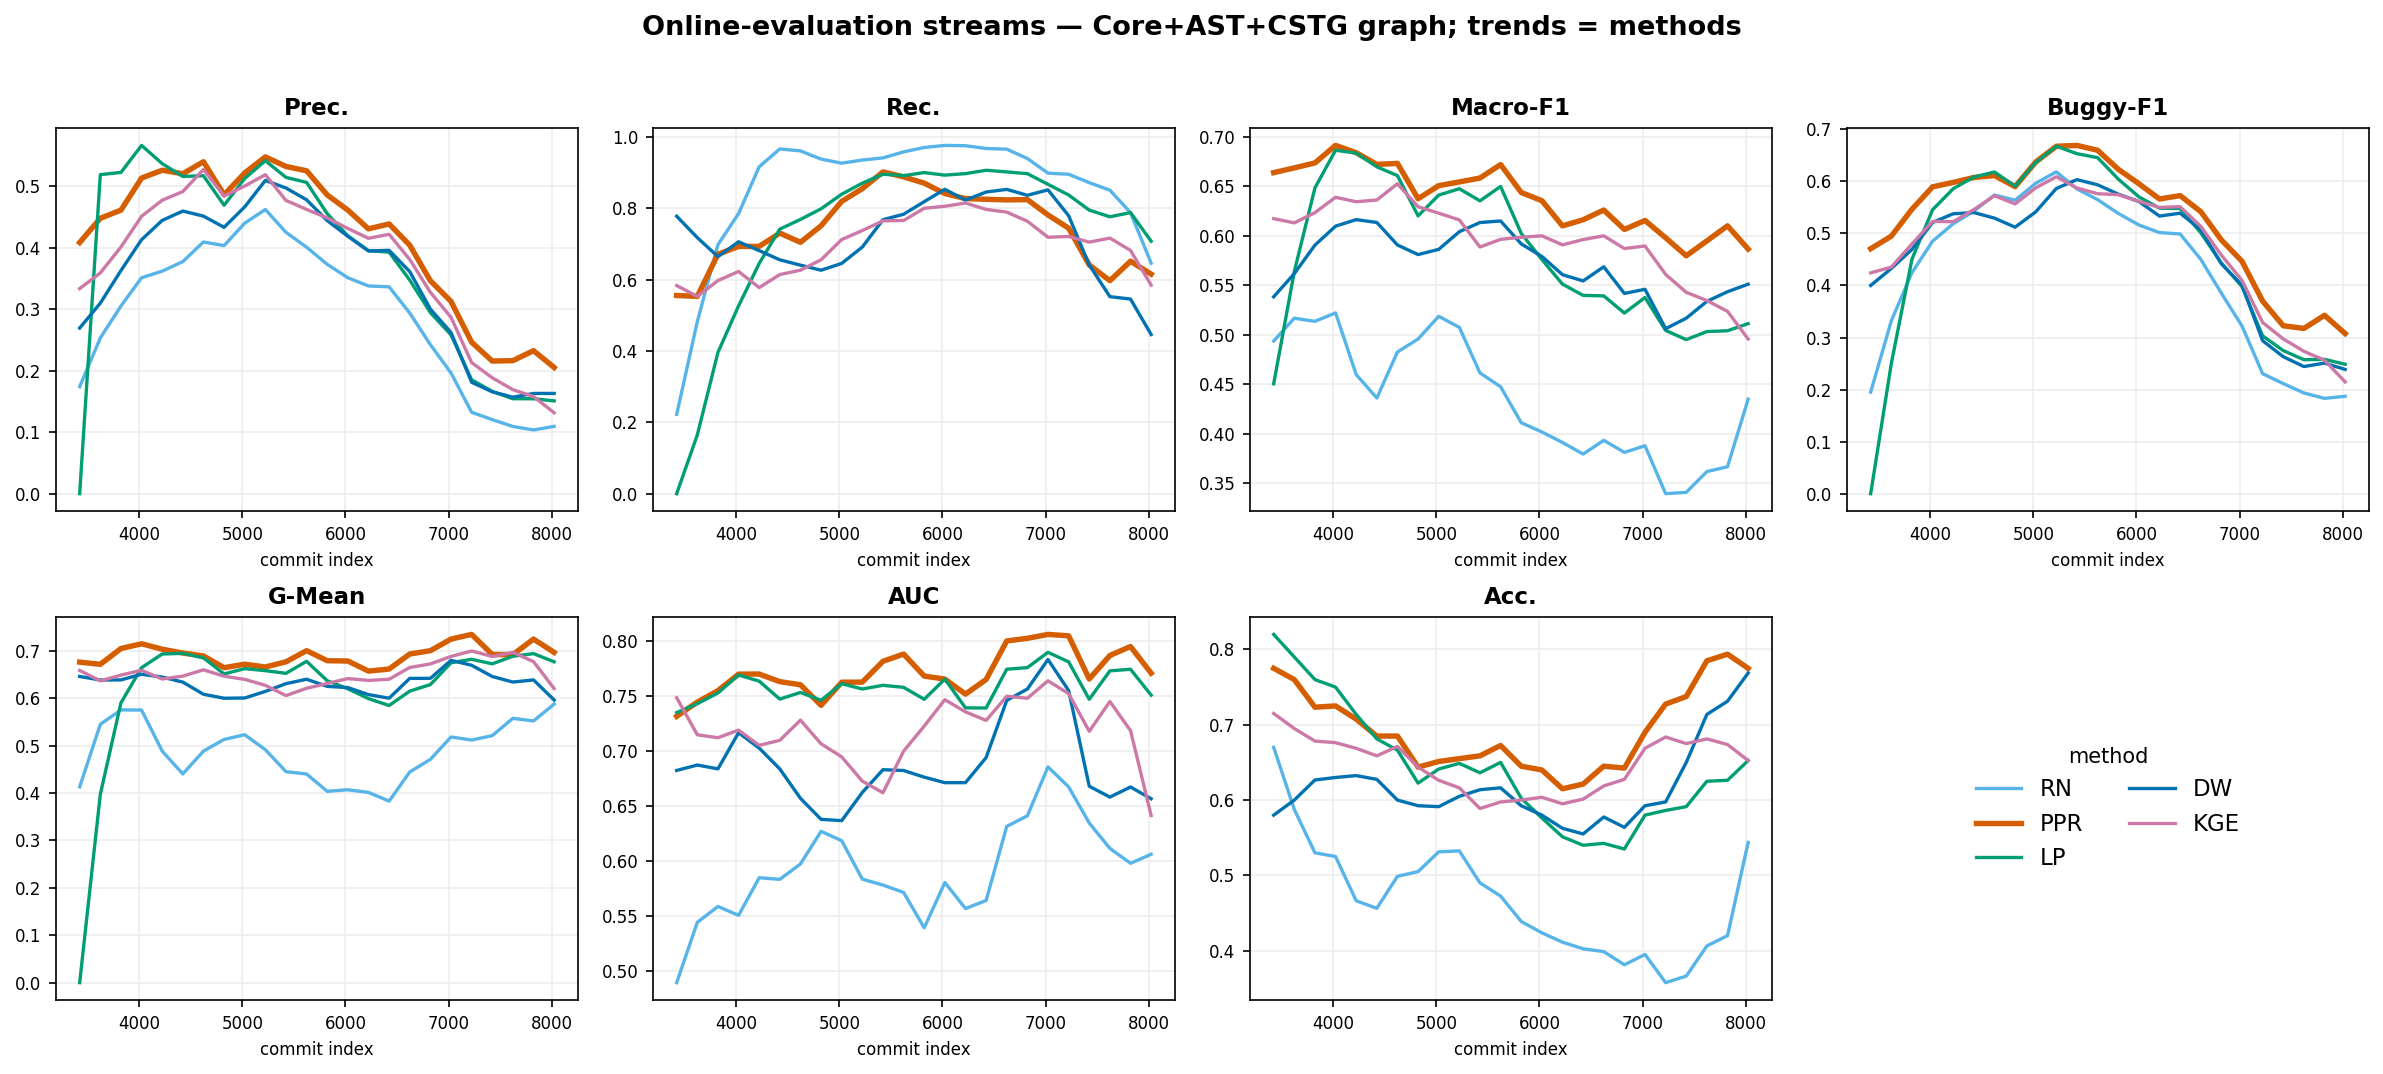

In [4]:
for g in GRAPHS:
    display(Image(filename=str(FIG / f"fig_final_bygraph_{g}.png")))

## 3. Fusion ablation — best combination of the five methods

We fuse the five methods on the **final graph** by prequential logistic-regression
stacking and evaluate **all $2^5-1=31$ combinations** on the seven metrics. The
final fusion is chosen to balance **load** (fewer methods) and **performance**
(especially Macro-F1 and G-Mean): the smallest combination within a small tolerance
of the best $(\text{Macro-F1}+\text{G-Mean})/2$.

In [5]:
FF = pickle.load(open(OUT / "final_fusion_results.pkl", "rb"))
p1 = FF["part1"]; chosen = FF["chosen"]
def bal(v): return 0.5*(v["metrics"]["Macro_F1"] + v["metrics"]["G_Mean"])
rows = [{"fusion":k, "n":v["n"], "balance":bal(v),
         **{lbl:v["metrics"][mk] for mk,lbl in M7}} for k,v in p1.items()]
abl = pd.DataFrame(rows).sort_values("balance", ascending=False).reset_index(drop=True)
abl.insert(0, "rank", abl.index+1)
def hl(row):
    return ["background:#d5efdf;font-weight:bold" if row["fusion"]==chosen else "" for _ in row]
display(abl.style.hide(axis="index").format({"balance":"{:.3f}", **{l:"{:.3f}" for _,l in M7}})
        .apply(hl, axis=1)
        .set_caption(f"All 31 fusions ranked by (Macro-F1+G-Mean)/2 — chosen: {chosen} (highlighted)"))
print(f"CHOSEN FUSION  F = {chosen}  (fewest methods within {0.005} of the best balance)")

rank,fusion,n,balance,Prec.,Rec.,Macro-F1,Buggy-F1,G-Mean,AUC,Acc.
1,RN+PPR,2,0.701,0.443,0.802,0.670,0.571,0.731,0.787,0.701
2,RN+PPR+LP,3,0.698,0.437,0.811,0.666,0.568,0.729,0.788,0.694
3,RN+PPR+LP+DW+KGE,5,0.695,0.442,0.767,0.668,0.561,0.723,0.787,0.702
4,RN+PPR+LP+KGE,4,0.691,0.445,0.729,0.668,0.553,0.714,0.783,0.707
5,RN+PPR+LP+DW,4,0.690,0.436,0.765,0.663,0.556,0.718,0.788,0.696
6,PPR,1,0.689,0.431,0.787,0.659,0.557,0.719,0.782,0.689
7,RN+LP+DW+KGE,4,0.688,0.437,0.747,0.662,0.552,0.714,0.773,0.699
8,RN+PPR+DW+KGE,4,0.686,0.432,0.760,0.658,0.551,0.714,0.783,0.692
9,PPR+LP+DW+KGE,4,0.685,0.436,0.732,0.661,0.547,0.710,0.782,0.699
10,PPR+LP+DW,3,0.684,0.425,0.792,0.653,0.553,0.715,0.783,0.682


CHOSEN FUSION  F = RN+PPR  (fewest methods within 0.005 of the best balance)


**Stream plots (Part 1)** — 7 metric panels; trends = the chosen fusion **F** (bold) and the five single methods:

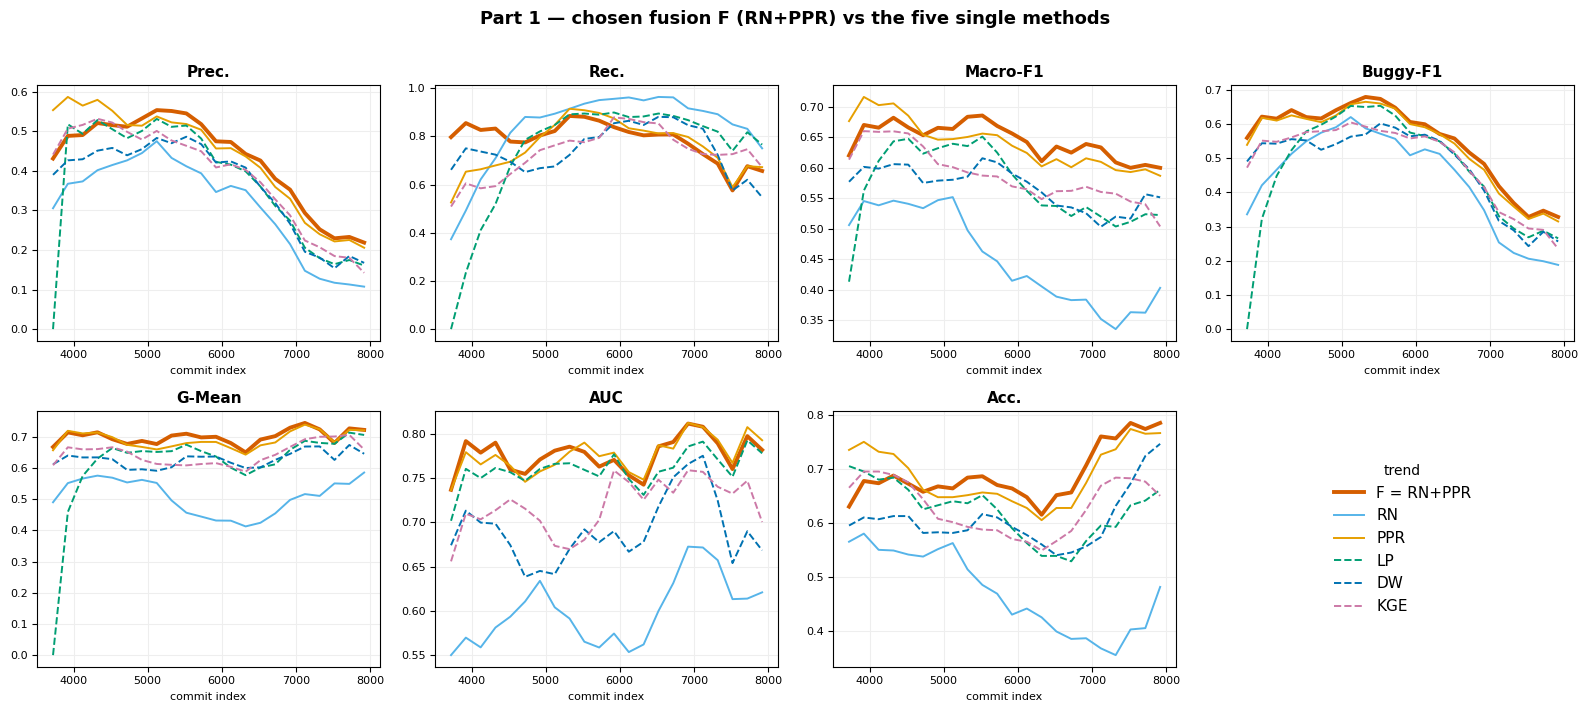

In [6]:
display(Image(filename=str(FIG.parent / "final" / "fig_final_fusion_part1.png")))

## 4. Adding CSTG (G) and JIT metrics (M) to the fusion

We append the CSTG semantic channel **G** and the non-graph JIT metrics **M** (and
both) to the chosen graph-method fusion **F**, to see whether they add anything.

fusion,Prec.,Rec.,Macro-F1,Buggy-F1,G-Mean,AUC,Acc.
F,0.443,0.802,0.670,0.571,0.731,0.787,0.701
F+G,0.527,0.755,0.729,0.621,0.766,0.844,0.771
F+M,0.419,0.798,0.648,0.549,0.712,0.787,0.675
F+G+M,0.548,0.722,0.736,0.623,0.762,0.844,0.784


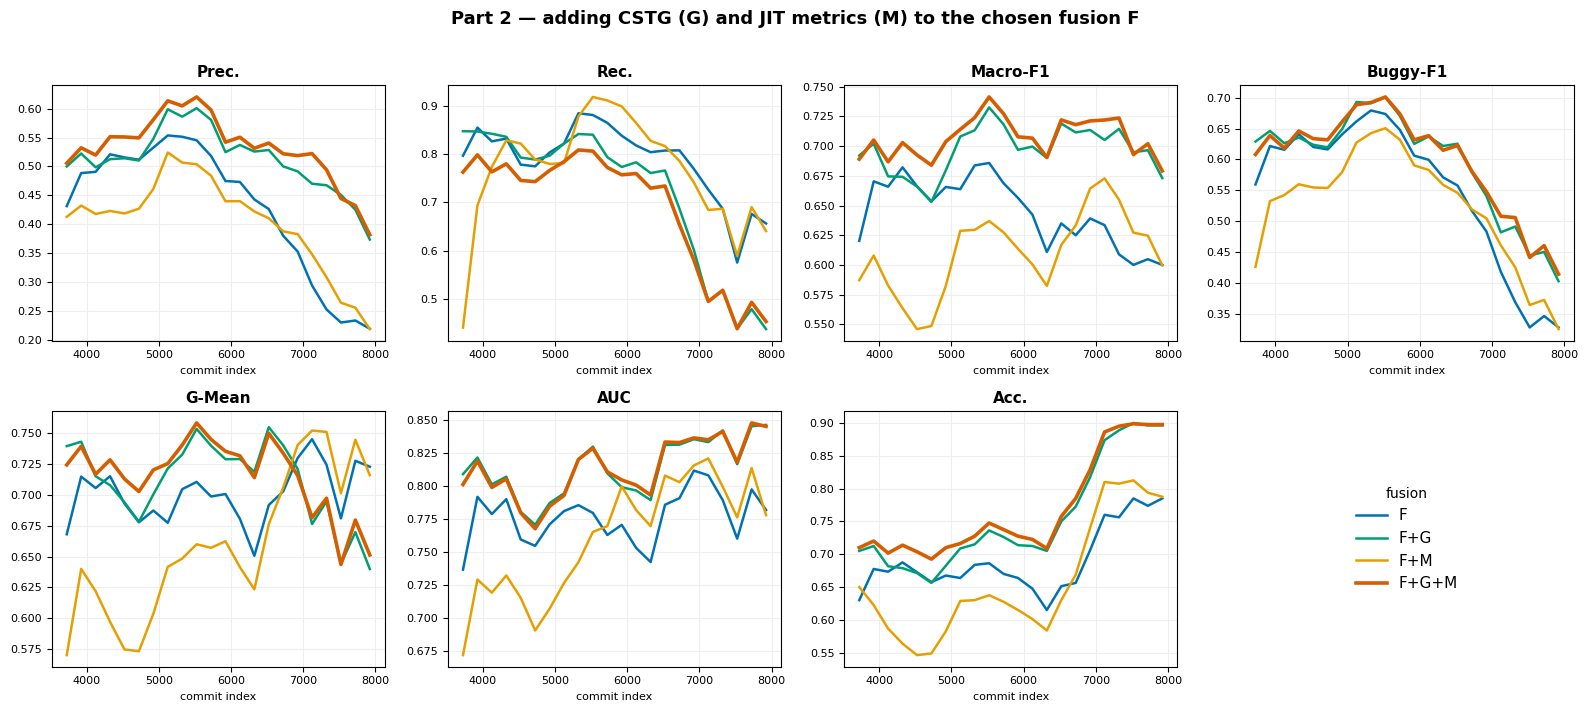

In [7]:
p2 = FF["part2"]
rows = [{"fusion":name, **{lbl:p2[name]["metrics"][mk] for mk,lbl in M7}}
        for name in ["F","F+G","F+M","F+G+M"]]
p2df = pd.DataFrame(rows)
display(p2df.style.hide(axis="index").format({l:"{:.3f}" for _,l in M7})
        .highlight_max(axis=0, color="#d5efdf")
        .set_caption(f"F = {chosen}; effect of adding CSTG (G) and JIT metrics (M)"))
display(Image(filename=str(FIG.parent / "final" / "fig_final_fusion_part2.png")))

**What this shows.** Adding **G (CSTG) gives a large jump**
(Macro-F1 and AUC rise sharply); adding **M (JIT metrics) alone *hurts*** and adds
nothing over G (F+G+M ≈ F+G). So the recommended deployed model is the purely
graph-native **F + G** (= the chosen graph-method fusion plus the CSTG channel),
**without the non-graph JIT metrics** — consistent with the rest of the study.

## 5. Findings

- **Graph richness helps.** For the stronger methods (PPR, LP, DW) the metrics rise
  from Core to the final **Core+AST+CSTG** graph — the CSTG term-hubs let the
  walks/embeddings absorb the semantic signal. **PPR on the final graph is the best
  single (method, graph) cell** (Buggy-F1 ≈ 0.555, AUC ≈ 0.78).
- **PPR is the strongest method** on the informative graphs, with LP and the
  embeddings (DW, KGE) close behind; **RN** (pure relational neighbour) is flat and
  actually prefers the Core graph — its signal is relational, and structural/semantic
  hubs dilute a one-hop vote.
- The ordering holds **across the whole stream** (Section 2), not just at the end,
  and across all seven metrics — so the choice of the five methods and the final KG
  is robust, not an artefact of one operating point.
- These five methods are the inputs to the deployed **fusion** on the final KG
  (reported separately); their combination on the richest graph gives the best
  performance, which is exactly the intended design.

## 6. Reproduce
```bash
python inference/run_final_experiments.py          # 5 methods x 6 graphs, 7 metrics + trajectories
python inference/make_final_experiments_report.py  # tables + 35 + 42 stream plots
python inference/run_final_fusion.py               # 31-combo fusion ablation + F/F+G/F+M/F+G+M
```